# Comparing Load 2 vs Load 3 params

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import sys 

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
import model
from model import generate_input_stim_letters


sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import importlib

2024-12-16 16:22:52.371198: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-16 16:22:52.377235: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-16 16:22:52.425148: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-16 16:22:52.478065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-16 16:22:52.518550: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Instructions for updating:
non-resource variables are not supported in the long term


## Get models, one load 2 and one load 3

In [2]:
# get load 2 model
model_dir_2 = '/home/nuttidalab/Documents/spikeRNN/models/letters/load_2'
model_fnames_2 = [f for f in os.listdir(model_dir_2) if 'N_400' in f]
mat_data_2 = scipy.io.loadmat(os.path.join(model_dir_2, model_fnames_2[0])) # grab 1 model

# get load 3 model
model_dir_3 = '/home/nuttidalab/Documents/spikeRNN/models/letters/load_3'
model_fnames_3 = [f for f in os.listdir(model_dir_3) if 'N_400' in f]
mat_data_3 = scipy.io.loadmat(os.path.join(model_dir_3, model_fnames_3[0])) # grab 1 model

In [3]:
print(model_fnames_2[0])
print(model_fnames_3[0])

Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_07_003605.mat
Task_letters_N_400_Taus_4.0_25.0_Act_sigmoid_2024_12_06_054931.mat


In [4]:
# print saved params
for k in mat_data_2.keys():
    print(k)

__header__
__version__
__globals__
x0
r0
w0
taus_gaus0
w_in0
u
o
w
x
target
w_out
r
m
som_m
N
exc
inh
w_in
b_out
som_N
losses
taus
eval_perf_mean
eval_loss_mean
eval_os
eval_labels
taus_gaus
tr
activation
all_perfs
opt_scaling_factor
scaling_factors
stable_perfs
spike_perf_mean


## Compare params

In [5]:
# compare params
mats = [mat_data_2, mat_data_3]
labels = ['load 2', 'load 3']

### Compare W_out

2024-12-16 17:13:36,126 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-12-16 17:13:36,129 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


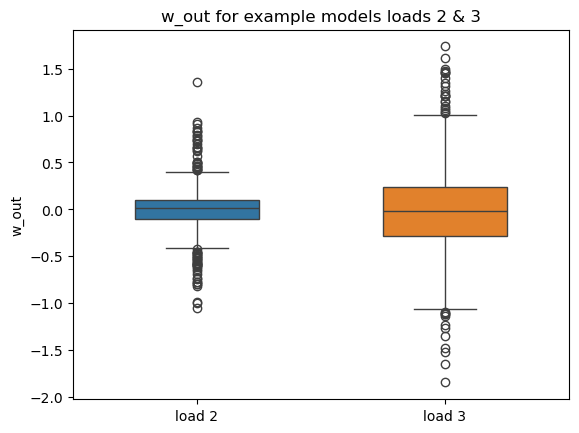

In [36]:
# w_out first

import seaborn as sns

w_out = []
for i, mat in enumerate(mats):
    w_out.append(np.squeeze(mat['w_out']))

# plot boxplot
plt.figure()
sns.boxplot(data=w_out, width=0.5)
plt.xticks([0, 1], labels)
plt.ylabel('w_out')
plt.title('w_out for example models loads 2 & 3')
plt.show()

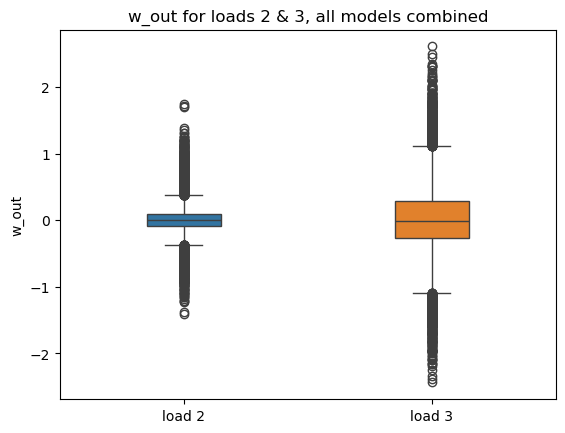

In [10]:
# now for all models

w_outs = []
for load in [2, 3]:
    model_dir = f'/home/nuttidalab/Documents/spikeRNN/models/letters/load_{load}'
    model_fnames = [f for f in os.listdir(model_dir) if 'N_400' in f]
    w_out = []
    for model_fname in model_fnames:
        mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname)) # grab 1 model
        w_out.append(np.squeeze(mat_data['w_out']))
    w_outs.append(np.array(w_out).reshape(-1))

# plot boxplot
plt.figure()
sns.boxplot(data=w_outs, width=0.3)    
plt.xticks([0, 1], ['load 2', 'load 3'])
plt.ylabel('w_out')
plt.title('w_out for loads 2 & 3, all models combined')
plt.show()    

### rs

In [44]:
rs = scipy.io.loadmat('/home/nuttidalab/Documents/spikeRNN/temp/rs_load2+3.mat')['all_rs']
print(rs.shape)

(2, 400, 30000)


In [ ]:
# get load 2 model
model_dir_2 = '/home/nuttidalab/Documents/spikeRNN/models/letters/load_2'
model_fnames_2 = [f for f in os.listdir(model_dir_2) if '12_06_210950' in f]
mat_data_2 = scipy.io.loadmat(os.path.join(model_dir_2, model_fnames_2[0])) # grab 1 model

# get load 3 model
model_dir_3 = '/home/nuttidalab/Documents/spikeRNN/models/letters/load_3'
model_fnames_3 = [f for f in os.listdir(model_dir_3) if '12_05_111023' in f]
mat_data_3 = scipy.io.loadmat(os.path.join(model_dir_3, model_fnames_3[0])) # grab 1 model

exc_inds = [np.where(mat_data_2['inh'] == 0)[0], np.where(mat_data_3['inh'] == 0)[0]]
inh_inds = [np.where(mat_data_2['inh'] == 1)[0], np.where(mat_data_3['inh'] == 1)[0]]

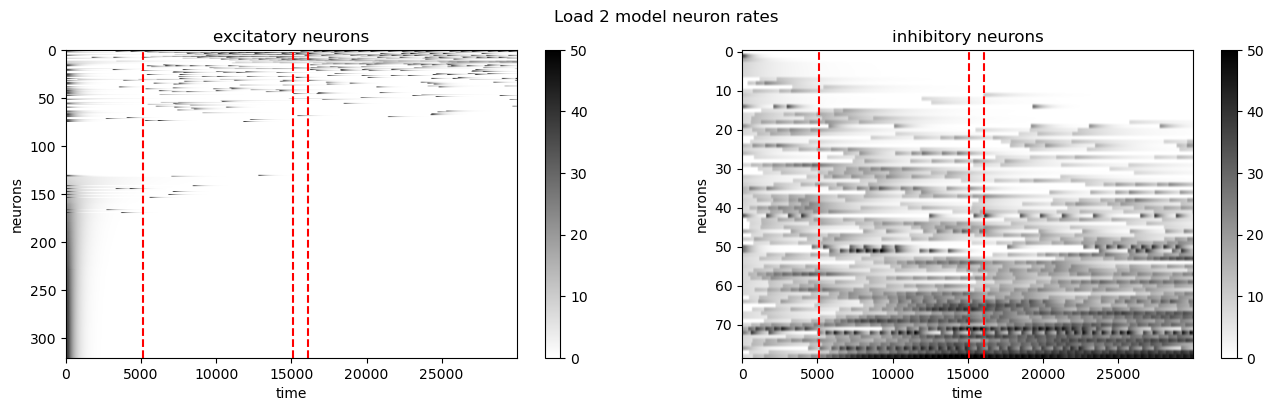

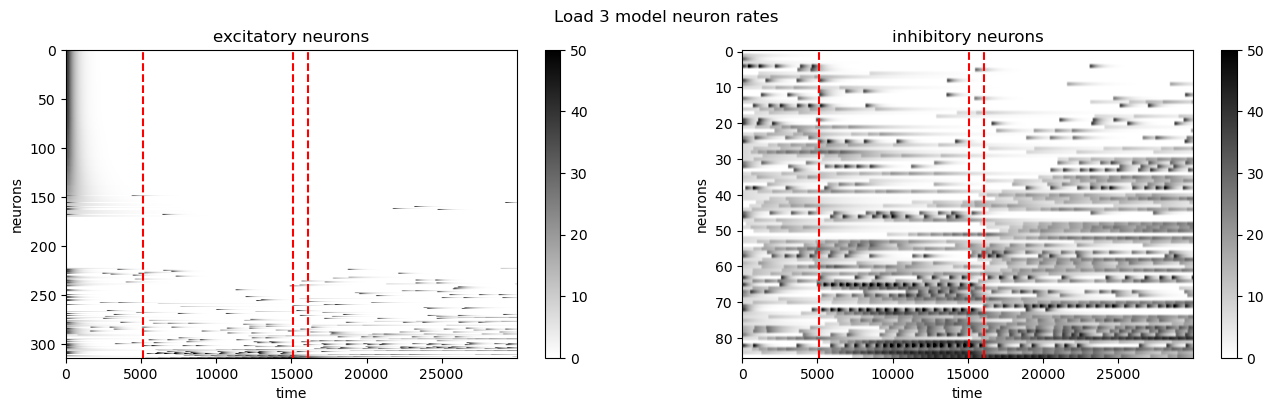

In [54]:
importlib.reload(vu)
for i, r in enumerate(rs):
    vu.plot_neuron_rates(r.T, exc_inds[i], inh_inds[i],
                     stim_on = 51*100, stim_dur = 100*100, delay=10*100, vmin=0, vmax=50,
                     sort=1, suptitle= f'Load {i+2} model neuron rates')

### spks

In [11]:
!pip install rastermap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 98.2 MB/s eta 0:00:00:00:0100:01


In [15]:
from rastermap import Rastermap

In [13]:
spks = scipy.io.loadmat('/home/nuttidalab/Documents/spikeRNN/temp/spks_load2+3.mat')['spks']

In [34]:
# get load 2 model
model_dir_2 = '/home/nuttidalab/Documents/spikeRNN/models/letters/load_2'
model_fnames_2 = [f for f in os.listdir(model_dir_2) if '12_06_210950' in f]
mat_data_2 = scipy.io.loadmat(os.path.join(model_dir_2, model_fnames_2[0])) # grab 1 model
exc_ind_2 = np.where(mat_data_2['exc'] == 1)[0]

# get load 3 model
model_dir_3 = '/home/nuttidalab/Documents/spikeRNN/models/letters/load_3'
model_fnames_3 = [f for f in os.listdir(model_dir_3) if '12_05_111023' in f]
mat_data_3 = scipy.io.loadmat(os.path.join(model_dir_3, model_fnames_3[0])) # grab 1 model
exc_ind_3 = np.where(mat_data_3['exc'] == 1)[0]

In [14]:
spks_2 = spks[0,:,:]
spks_3 = spks[1,:,:]
print(spks_2.shape)
print(spks_3.shape)

(400, 30000)
(400, 30000)


2024-12-16 17:26:01,752 [INFO] normalizing data across axis=1
2024-12-16 17:26:01,782 [INFO] projecting out mean along axis=0
2024-12-16 17:26:01,869 [INFO] data normalized, 0.12sec
2024-12-16 17:26:01,870 [INFO] sorting activity: 272 valid samples by 30000 timepoints


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2024-12-16 17:26:02,095 [INFO] n_PCs = 20 computed, 0.34sec
2024-12-16 17:26:02,335 [INFO] 58 clusters computed, time 0.58sec


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(


2024-12-16 17:26:02,755 [INFO] clusters sorted, time 1.00sec
2024-12-16 17:26:02,778 [INFO] clusters upsampled, time 1.03sec
2024-12-16 17:26:02,849 [INFO] rastermap complete, time 1.10sec
2024-12-16 17:26:02,916 [INFO] normalizing data across axis=1
2024-12-16 17:26:02,923 [INFO] projecting out mean along axis=0
2024-12-16 17:26:02,944 [INFO] data normalized, 0.03sec
2024-12-16 17:26:02,945 [INFO] sorting activity: 77 valid samples by 30000 timepoints
2024-12-16 17:26:03,057 [INFO] n_PCs = 20 computed, 0.14sec


...

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(


2024-12-16 17:26:03,963 [INFO] clusters sorted, time 0.71sec
2024-12-16 17:26:03,985 [INFO] clusters upsampled, time 0.73sec
2024-12-16 17:26:04,058 [INFO] rastermap complete, time 0.80sec
2024-12-16 17:26:04,124 [INFO] normalizing data across axis=1
2024-12-16 17:26:04,132 [INFO] projecting out mean along axis=0
2024-12-16 17:26:04,149 [INFO] data normalized, 0.03sec
2024-12-16 17:26:04,150 [INFO] sorting activity: 85 valid samples by 30000 timepoints


/tmp/ipykernel_950783/654343695.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k|" (-> color='k'). The keyword argument will take precedence.
  axs[j, i].plot(spike_times, np.ones_like(spike_times) * (k + 1), 'k|', markersize=5, color = colors[j])
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2024-12-16 17:26:04,343 [INFO] n_PCs = 20 computed, 0.22sec
2024-12-16 17:26:04,361 [INFO] 36 clusters computed, time 0.24sec
2024-12-16 17:26:04,479 [INFO] clusters sorted, time 0.35sec
2024-12-16 17:26:04,488 [INFO] clusters upsampled, time 0.36sec
2024-12-16 17:26:04,521 [INFO] rastermap complete, time 0.40sec


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(
/tmp/ipykernel_950783/654343695.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k|" (-> color='k'). The keyword argument will take precedence.
  axs[j, i].plot(spike_times, np.ones_like(spike_times) * (k + 1), 'k|', markersize=5, color = colors[j])


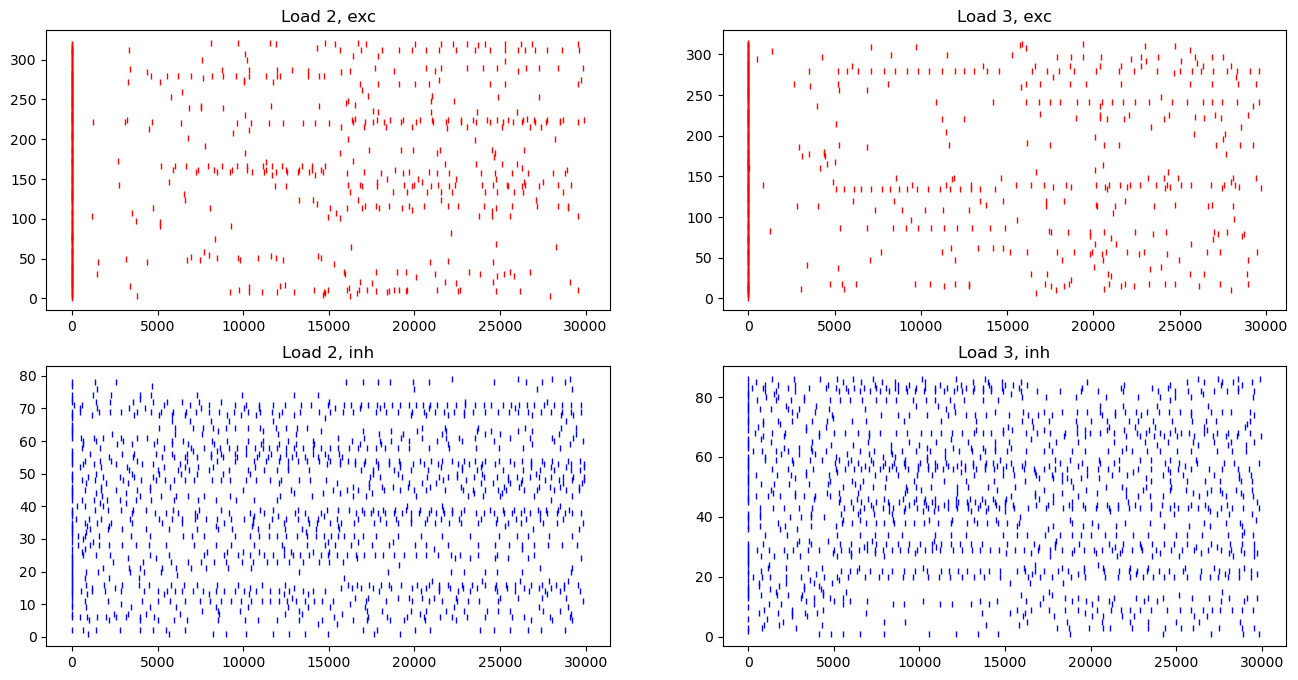

In [43]:
exc_inds = [exc_ind_2, exc_ind_3]
inh_inds = [np.where(mat_data_2['inh'] == 1)[0], np.where(mat_data_3['inh'] == 1)[0]]
neur_labels = ['exc', 'inh']

fig, axs = plt.subplots(2,2, figsize=(16,8))
colors = ['r', 'b']
for i, load in enumerate([2,3]):
    for j, neur in enumerate([exc_inds[i], inh_inds[i]]):
        model = Rastermap(n_PCs=20, n_clusters=100, locality=0.75, time_lag_window=5).fit(spks[i,neur,:].astype(np.float64))
        isort = model.isort
        for k, neuron_spikes in enumerate(spks[i,neur,:]):
            spike_times = np.where(neuron_spikes == 1)[0]
            axs[j, i].plot(spike_times, np.ones_like(spike_times) * (k + 1), 'k|', markersize=5, color = colors[j])
            axs[j, i].set_title(f'Load {load}, {neur_labels[j]}')

plt.show()

2024-12-16 16:57:56,071 [INFO] normalizing data across axis=1
2024-12-16 16:57:56,135 [INFO] projecting out mean along axis=0
2024-12-16 16:57:56,240 [INFO] data normalized, 0.17sec
2024-12-16 16:57:56,241 [INFO] sorting activity: 349 valid samples by 30000 timepoints


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2024-12-16 16:57:57,429 [INFO] n_PCs = 200 computed, 1.36sec
2024-12-16 16:57:57,701 [INFO] 90 clusters computed, time 1.63sec


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(


2024-12-16 16:57:59,046 [INFO] clusters sorted, time 2.97sec
2024-12-16 16:57:59,091 [INFO] clusters upsampled, time 3.02sec
2024-12-16 16:57:59,208 [INFO] rastermap complete, time 3.14sec


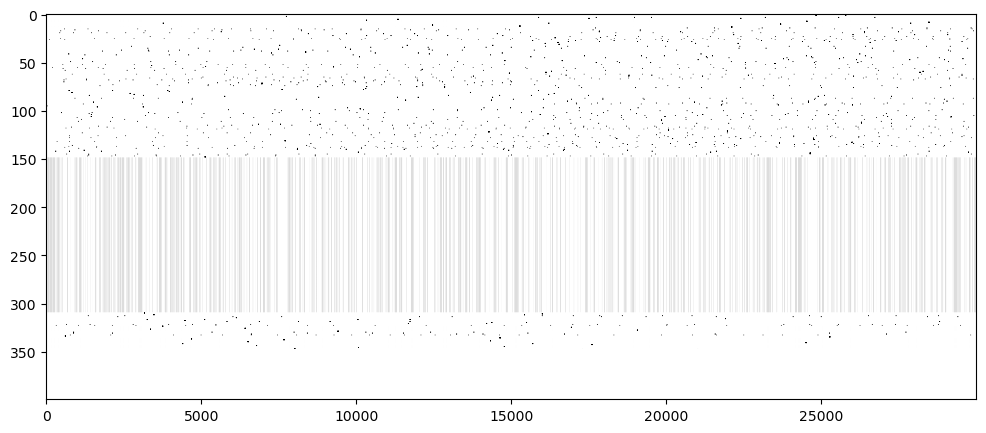

In [25]:
# fit rastermap
model = Rastermap(n_PCs=200, n_clusters=100, 
                  locality=0.75, time_lag_window=5).fit(spks_2.astype(np.float64))
y = model.embedding # neurons x 1
isort_2 = model.isort

# visualize binning over neurons
X_embedding = model.X_embedding

# plot
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)
ax.imshow(X_embedding, vmin=0, vmax=1.5, cmap="gray_r", aspect="auto")
plt.show()

2024-12-16 16:57:59,637 [INFO] normalizing data across axis=1
2024-12-16 16:57:59,689 [INFO] projecting out mean along axis=0
2024-12-16 16:57:59,796 [INFO] data normalized, 0.16sec
2024-12-16 16:57:59,796 [INFO] sorting activity: 346 valid samples by 30000 timepoints


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2024-12-16 16:58:00,982 [INFO] n_PCs = 200 computed, 1.34sec
2024-12-16 16:58:01,275 [INFO] 84 clusters computed, time 1.64sec


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:138: UserWarning: found fewer than half the n_clusters that the user specified, rerunning with random initialization
  warnings.warn(
/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/rastermap/cluster.py:148: UserWarning: found fewer clusters than user specified, try reducing n_clusters and/or reduce n_splits and/or increase n_PCs
  warnings.warn(


2024-12-16 16:58:02,510 [INFO] clusters sorted, time 2.87sec
2024-12-16 16:58:02,551 [INFO] clusters upsampled, time 2.91sec
2024-12-16 16:58:02,672 [INFO] rastermap complete, time 3.03sec


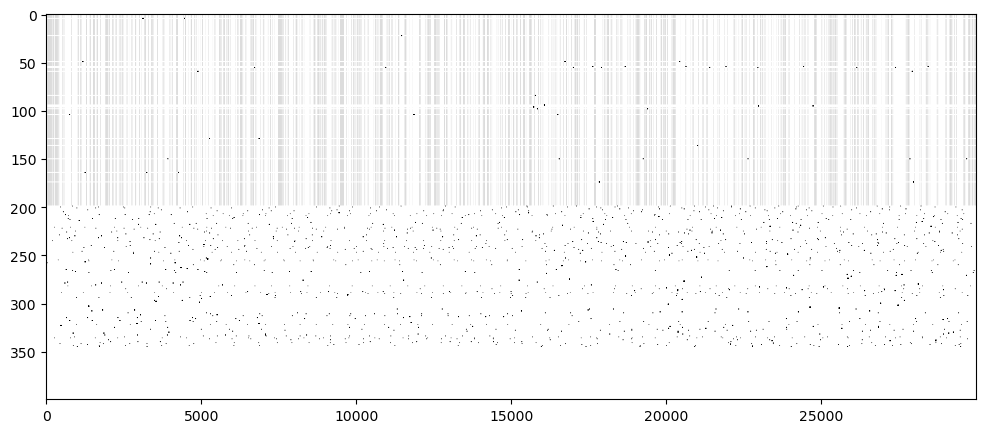

In [26]:
# fit rastermap
model = Rastermap(n_PCs=200, n_clusters=100, 
                  locality=0.75, time_lag_window=5).fit(spks_3.astype(np.float64))
y = model.embedding # neurons x 1
isort_3 = model.isort

# visualize binning over neurons
X_embedding = model.X_embedding

# plot
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)
ax.imshow(X_embedding, vmin=0, vmax=1.5, cmap="gray_r", aspect="auto")
plt.show()

In [28]:
len(isort_2)

400

/tmp/ipykernel_950783/2402861664.py:8: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k|" (-> color='k'). The keyword argument will take precedence.
  axs[0].plot(spike_times, np.ones_like(spike_times) * (i + 1), 'k|', markersize=5, c=color)  # 'k|' plots vertical lines
/tmp/ipykernel_950783/2402861664.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k|" (-> color='k'). The keyword argument will take precedence.
  axs[1].plot(spike_times, np.ones_like(spike_times) * (i + 1), 'k|', markersize=5, c=color)  # 'k|' plots vertical lines


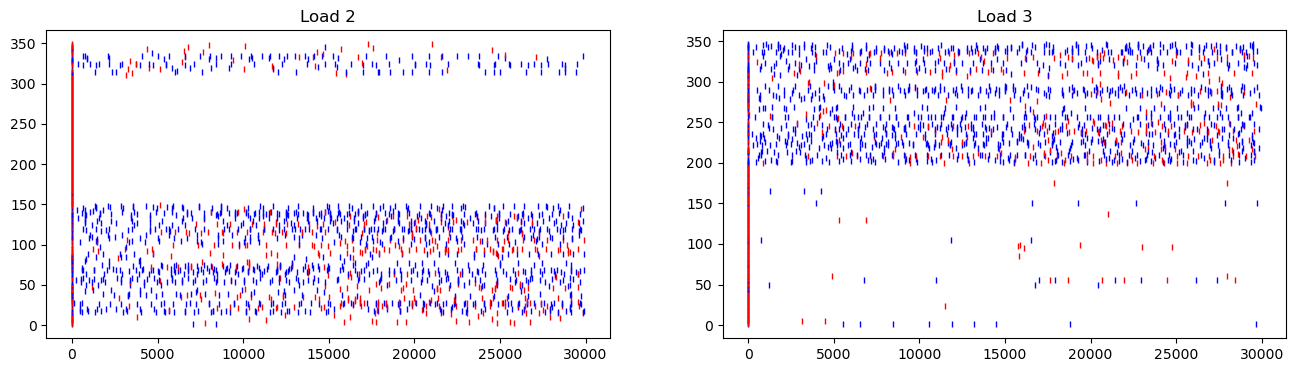

In [35]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
for i, neuron_spikes in enumerate(spks_2[isort_2, :]):
    if isort_2[i] in np.where(mat_data_2['exc'])[0]:
        color = 'r'
    else:
        color = 'b'
    spike_times = np.where(neuron_spikes == 1)[0]  # Get the indices where the spike is 1
    axs[0].plot(spike_times, np.ones_like(spike_times) * (i + 1), 'k|', markersize=5, c=color)  # 'k|' plots vertical lines
    axs[0].set_title('Load 2')
for i, neuron_spikes in enumerate(spks_3[isort_3, :]):
    if isort_3[i] in np.where(mat_data_3['exc'])[0]:
        color = 'r'
    else:
        color = 'b'
    spike_times = np.where(neuron_spikes == 1)[0]  # Get the indices where the spike is 1
    axs[1].plot(spike_times, np.ones_like(spike_times) * (i + 1), 'k|', markersize=5, c=color)  # 'k|' plots vertical lines
    axs[1].set_title('Load 3')
plt.show()